In [1]:
# Load config and ingest the Stage 2 parquet; print row count, video count, offsets, and basic stats.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

pairs_path = Path(config['data']['pairs_folder']) / 'detection_pairs.parquet'
df = pd.read_parquet(pairs_path)

print(f"Loaded {len(df):,} pairs from {pairs_path}")
print(f"Videos: {df['video_name'].nunique()}, Offsets: {sorted(df['offset'].unique())}")
print()
print(df[['mean_iou', 'match_quality', 'n_matched', 'num_detections_a', 'num_detections_b']].describe())
df.head()


Loaded 836,786 pairs from /home/whall/FrameDiff/data/pairs/detection_pairs.parquet
Videos: 100, Offsets: [np.int64(1), np.int64(3), np.int64(5), np.int64(7), np.int64(11), np.int64(13)]

            mean_iou  match_quality      n_matched  num_detections_a  \
count  836786.000000  836786.000000  836786.000000     836786.000000   
mean        0.651140       0.687726      14.152311         15.899818   
std         0.240543       0.345934       7.857258          8.205764   
min         0.000000       0.000000       0.000000          0.000000   
25%         0.516959       0.500000       7.000000          9.000000   
50%         0.714788       0.826087      14.000000         16.000000   
75%         0.840373       1.000000      20.000000         22.000000   
max         0.999519       1.000000      41.000000         43.000000   

       num_detections_b  
count     836786.000000  
mean          15.896895  
std            8.204101  
min            0.000000  
25%            9.000000  
50%     

,video_name,frame_num_a,frame_num_b,offset,num_detections_a,num_detections_b,n_matched,n_matched_well,mean_iou,match_quality
0,MVI_40864,1,2,1,24,23,23,23,0.938232,1.000000
1,MVI_40864,1,4,3,24,24,22,21,0.838036,0.954545
2,MVI_40864,1,6,5,24,27,23,22,0.767489,0.956522
3,MVI_40864,1,8,7,24,25,19,14,0.685427,0.736842
4,MVI_40864,1,12,11,24,25,19,11,0.567917,0.578947


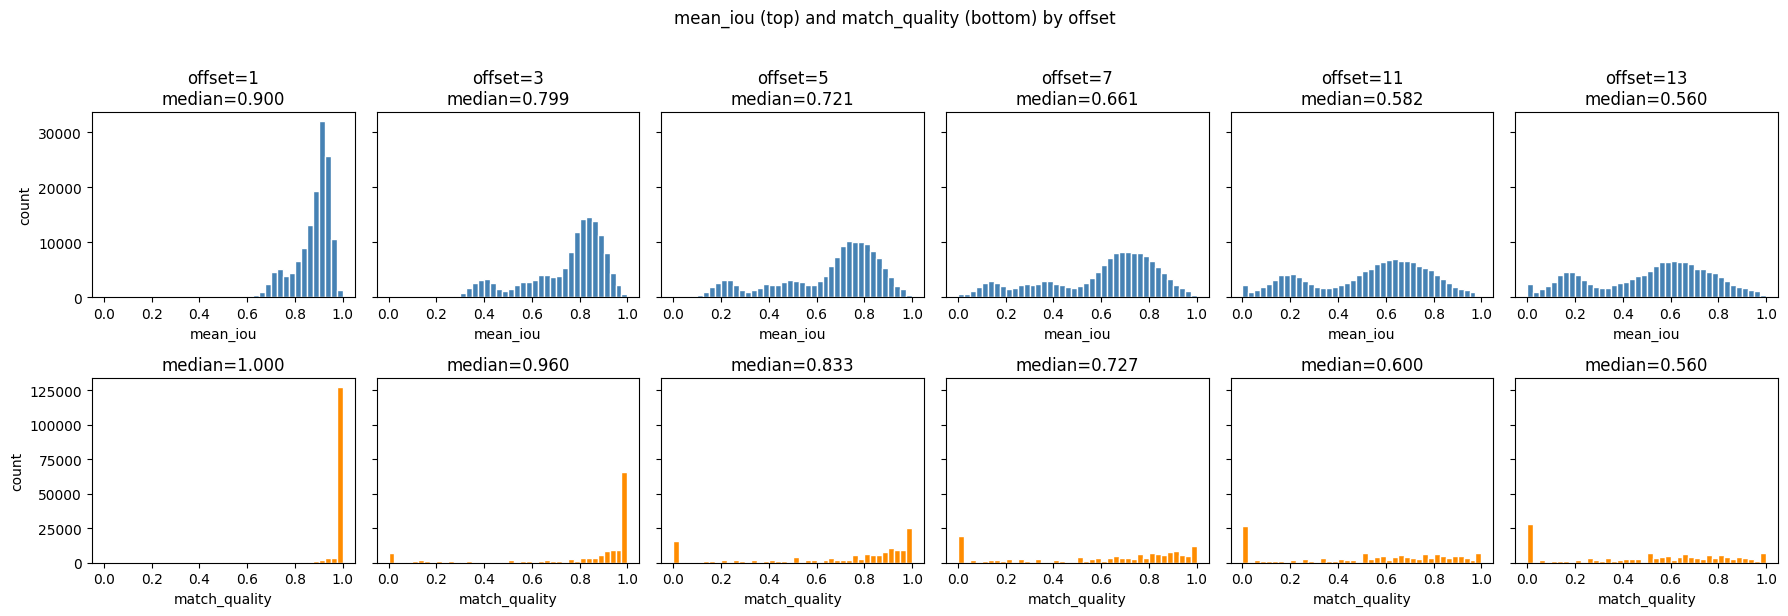

In [2]:
# Histogram mean_iou (top row) and match_quality (bottom row) faceted by temporal offset
offsets = sorted(df['offset'].unique())

fig, axes = plt.subplots(2, len(offsets), figsize=(3 * len(offsets), 6), sharey='row')
if len(offsets) == 1:
    axes = axes.reshape(2, 1)

for col_idx, off in enumerate(offsets):
    sub = df[df['offset'] == off]

    axes[0, col_idx].hist(sub['mean_iou'], bins=40, range=(0, 1),
                          color='steelblue', edgecolor='white')
    axes[0, col_idx].set_title(f'offset={off}\nmedian={sub["mean_iou"].median():.3f}')
    axes[0, col_idx].set_xlabel('mean_iou')
    if col_idx == 0:
        axes[0, col_idx].set_ylabel('count')

    axes[1, col_idx].hist(sub['match_quality'], bins=40, range=(0, 1),
                          color='darkorange', edgecolor='white')
    axes[1, col_idx].set_title(f'median={sub["match_quality"].median():.3f}')
    axes[1, col_idx].set_xlabel('match_quality')
    if col_idx == 0:
        axes[1, col_idx].set_ylabel('count')

fig.suptitle('mean_iou (top) and match_quality (bottom) by offset', y=1.02)
plt.tight_layout()
plt.show()


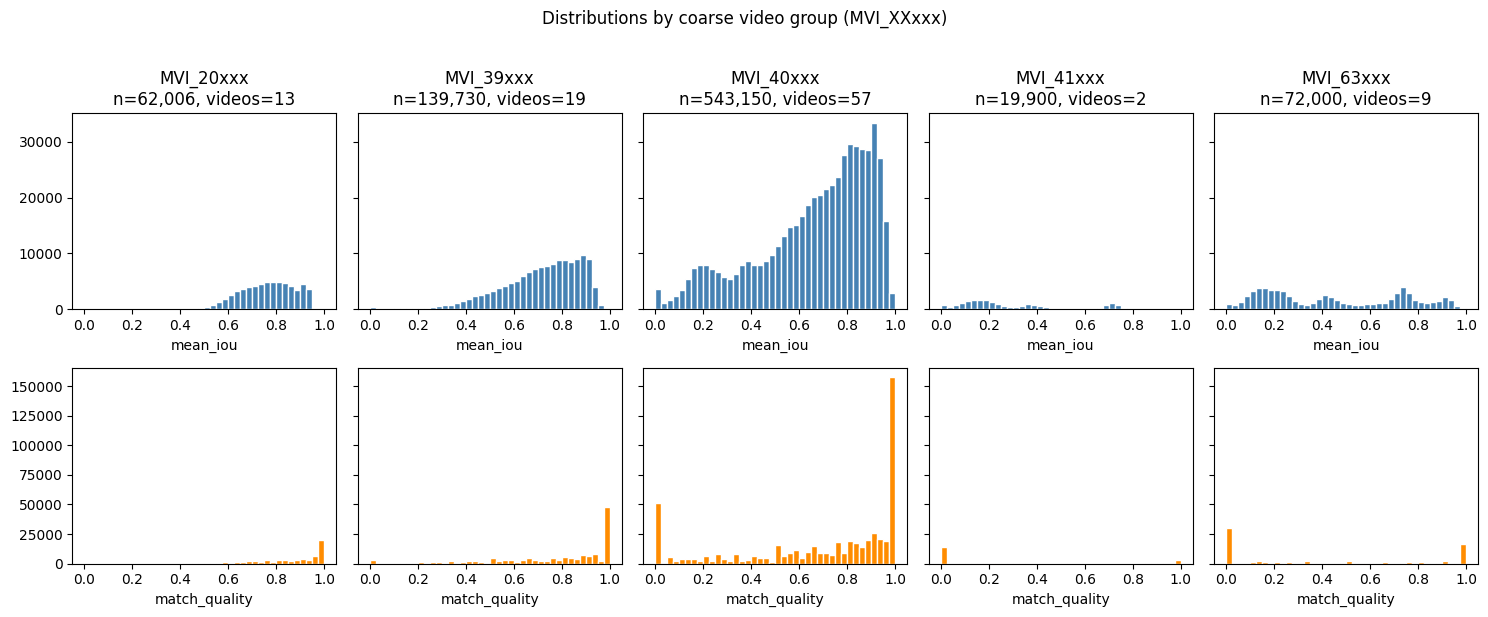

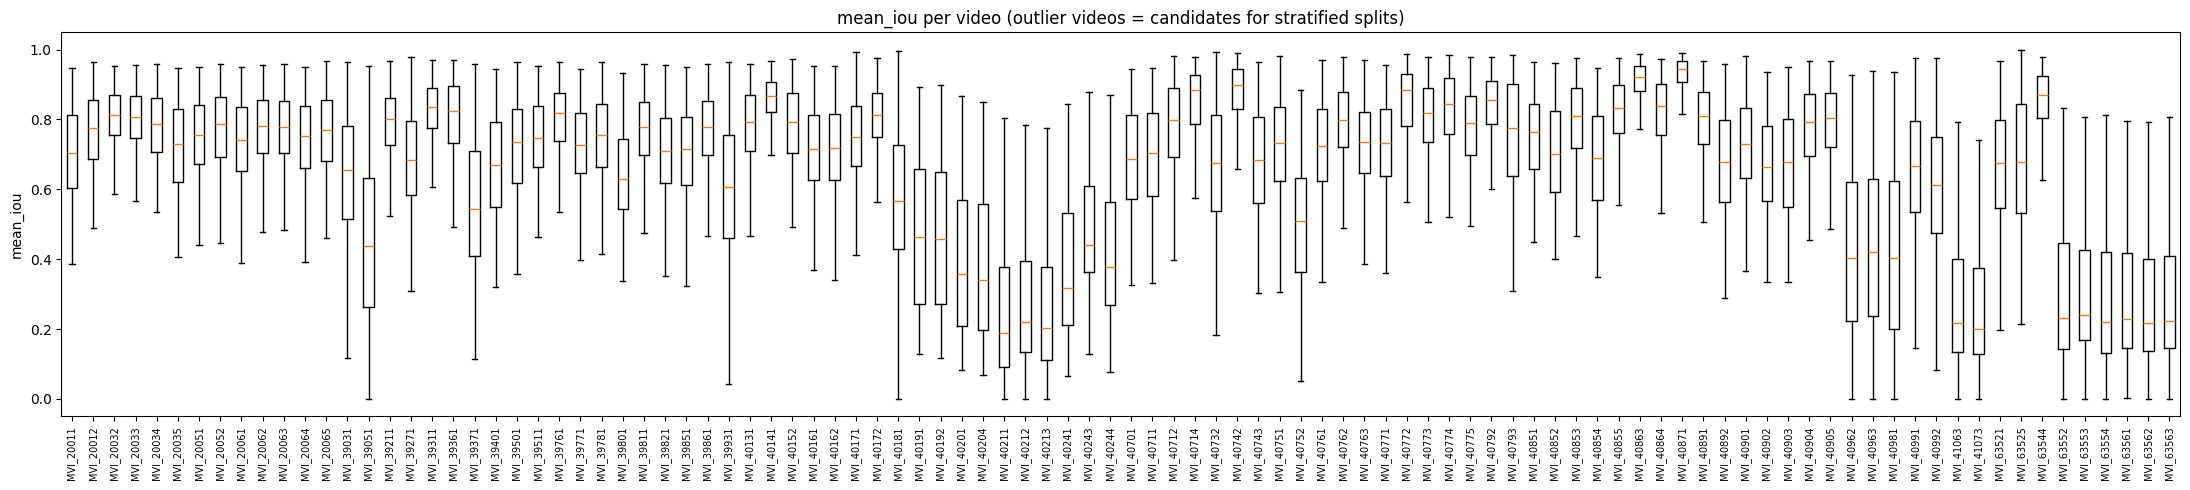

In [3]:
# Same metrics grouped by coarse camera/scene plus a per-video mean_iou boxplot to flag outlier videos.
df['video_group'] = df['video_name'].str.extract(r'MVI_(\d{2})')[0].apply(lambda x: f'MVI_{x}xxx')
groups = sorted(df['video_group'].unique())

fig, axes = plt.subplots(2, len(groups), figsize=(3 * len(groups), 6), sharey='row')
if len(groups) == 1:
    axes = axes.reshape(2, 1)

for col_idx, grp in enumerate(groups):
    sub = df[df['video_group'] == grp]
    axes[0, col_idx].hist(sub['mean_iou'], bins=40, range=(0, 1),
                          color='steelblue', edgecolor='white')
    axes[0, col_idx].set_title(f'{grp}\nn={len(sub):,}, videos={sub["video_name"].nunique()}')
    axes[0, col_idx].set_xlabel('mean_iou')

    axes[1, col_idx].hist(sub['match_quality'], bins=40, range=(0, 1),
                          color='darkorange', edgecolor='white')
    axes[1, col_idx].set_xlabel('match_quality')

fig.suptitle('Distributions by coarse video group (MVI_XXxxx)', y=1.02)
plt.tight_layout()
plt.show()

order = sorted(df['video_name'].unique())
data = [df.loc[df['video_name'] == v, 'mean_iou'].values for v in order]

fig, ax = plt.subplots(figsize=(max(12, len(order) * 0.22), 5))
ax.boxplot(data, showfliers=False)
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_ylabel('mean_iou')
ax.set_title('mean_iou per video (outlier videos = candidates for stratified splits)')
plt.tight_layout()
plt.show()


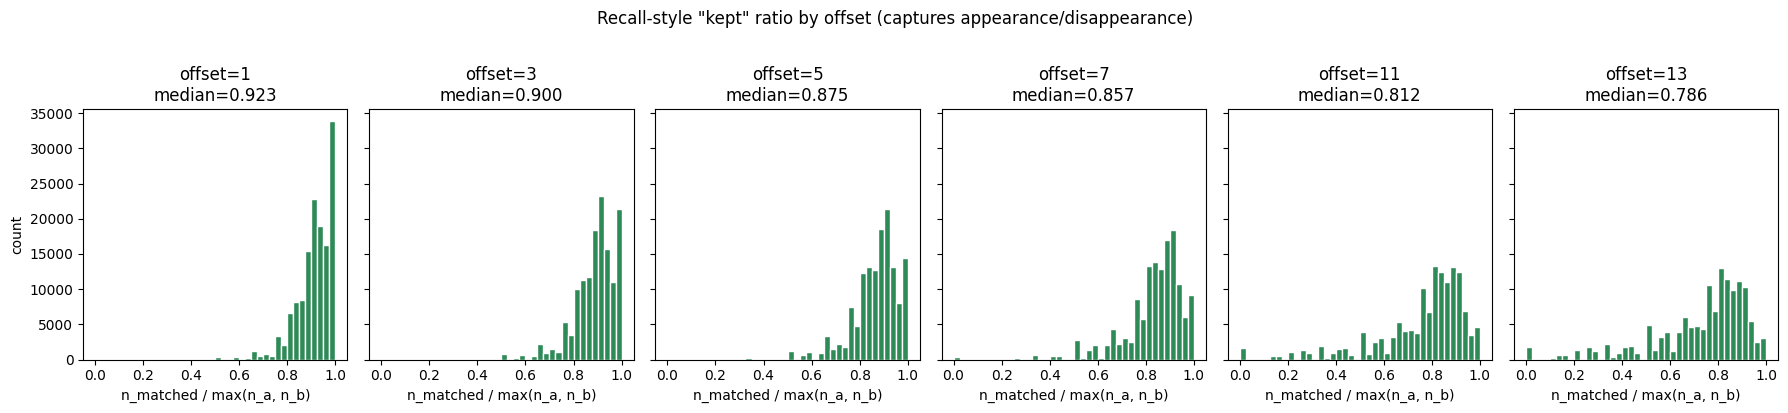

Correlation among signals:
               kept_ratio  mean_iou  match_quality
kept_ratio          1.000     0.570          0.529
mean_iou            0.570     1.000          0.957
match_quality       0.529     0.957          1.000


In [4]:
# Recall-style "kept" ratio (n_matched / max(n_a, n_b)) faceted by offset
df['kept_ratio'] = df['n_matched'] / df[['num_detections_a', 'num_detections_b']].max(axis=1).clip(lower=1)

fig, axes = plt.subplots(1, len(offsets), figsize=(3 * len(offsets), 4), sharey=True)
if len(offsets) == 1:
    axes = [axes]

for col_idx, off in enumerate(offsets):
    sub = df[df['offset'] == off]
    axes[col_idx].hist(sub['kept_ratio'], bins=40, range=(0, 1),
                       color='seagreen', edgecolor='white')
    axes[col_idx].set_title(f'offset={off}\nmedian={sub["kept_ratio"].median():.3f}')
    axes[col_idx].set_xlabel('n_matched / max(n_a, n_b)')
    if col_idx == 0:
        axes[col_idx].set_ylabel('count')

fig.suptitle('Recall-style "kept" ratio by offset (captures appearance/disappearance)', y=1.02)
plt.tight_layout()
plt.show()

corr = df[['kept_ratio', 'mean_iou', 'match_quality']].corr()
print("Correlation among signals:")
print(corr.round(3))


In [5]:
# P(mean_iou >= tau) table across (tau, offset) plus the offset=1 / mean_iou>0.9 spot check that prints a class-imbalance verdict.
thresholds = [0.5, 0.7, 0.8, 0.9, 0.95]
table = pd.DataFrame(index=thresholds, columns=offsets, dtype=float)
for off in offsets:
    sub = df[df['offset'] == off]
    for tau in thresholds:
        table.loc[tau, off] = (sub['mean_iou'] >= tau).mean()
table.index.name = 'tau'
table.columns.name = 'offset'

print("Fraction of pairs with mean_iou >= tau (rows) at each offset (columns):")
print(table.round(3).to_string())
print()

off1 = df[df['offset'] == 1]
frac_high = (off1['mean_iou'] > 0.9).mean()
print(f"Sanity check: at offset=1, fraction with mean_iou > 0.9 = {frac_high:.1%}")

if frac_high > 0.95:
    print("  -> Severe imbalance on the easiest task.")
    print("     Plan to oversample harder offsets (or weight loss by offset) during training.")
elif frac_high > 0.85:
    print("  -> Moderate imbalance. Worth weighting the loss by offset, but not catastrophic.")
else:
    print("  -> Healthy distribution; uniform sampling across offsets should be fine.")


Fraction of pairs with mean_iou >= tau (rows) at each offset (columns):
offset     1      3      5      7      11     13
tau                                             
0.50    0.999  0.878  0.768  0.707  0.627  0.594
0.70    0.969  0.703  0.555  0.408  0.273  0.244
0.80    0.840  0.496  0.272  0.179  0.114  0.106
0.90    0.497  0.109  0.055  0.037  0.029  0.031
0.95    0.085  0.019  0.013  0.010  0.009  0.010

Sanity check: at offset=1, fraction with mean_iou > 0.9 = 49.7%
  -> Healthy distribution; uniform sampling across offsets should be fine.
